# 04 - Optimisation des hyperparametres et seuil metier

**Auteur :** Gregory CRESPIN | **Date :** 30/01/2026 | **Version :** 1.0

---

DESCRIPTIF : Ce notebook optimise les hyperparametres des modeles avec Optuna,
trouve le seuil de decision optimal base sur le cout metier (FN=10, FP=1),
puis entraine le modele final sur toutes les donnees.

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import StratifiedKFold, train_test_split
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from src.metrics import evaluate_model, print_metrics
from utils.business_cost import find_optimal_threshold, calculate_business_cost_from_proba

# Configuration MLflow
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("credit_scoring_optimization")

<Experiment: artifact_location='file:///app/notebooks/../mlruns/822832716267716053', creation_time=1769781368745, experiment_id='822832716267716053', last_update_time=1769781368745, lifecycle_stage='active', name='credit_scoring_optimization', tags={}>

## 1. Chargement des données

In [2]:
# Charger les données
X_train = pd.read_csv('../data/X_train_prepared.csv')
y_train = pd.read_csv('../data/y_train_prepared.csv').iloc[:, 0]

# Split train/validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Train shape: {X_train_split.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (246008, 173)
Validation shape: (61503, 173)


## 2. Fonction de scoring personnalisée pour Optuna

In [3]:
def business_score_objective(y_true, y_proba):
    """
    Score métier pour Optuna. Plus élevé = meilleur.
    """
    optimal_threshold, min_cost, _ = find_optimal_threshold(y_true, y_proba)
    return -min_cost  # Score = -coût (plus élevé = meilleur)

## 3. Optimisation XGBoost avec Optuna

In [4]:
# Optimisation XGBoost avec Optuna
scale_pos_weight = (y_train_split == 0).sum() / (y_train_split == 1).sum()
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'aucpr'
    }
    model = xgb.XGBClassifier(**params)
    scores = []
    for train_idx, val_idx in skf.split(X_train_split, y_train_split):
        X_tr, X_v = X_train_split.iloc[train_idx], X_train_split.iloc[val_idx]
        y_tr, y_v = y_train_split.iloc[train_idx], y_train_split.iloc[val_idx]
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_v)[:, 1]
        scores.append(business_score_objective(y_v, y_proba))
    return np.mean(scores)

print("[OPTUNA] Optimisation XGBoost...")
xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10))
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f"\n[OK] Meilleurs parametres: {xgb_study.best_params}")
print(f"Meilleur score: {xgb_study.best_value:.4f}")

# Créer le meilleur modèle
xgb_best_params = {**xgb_study.best_params, 'scale_pos_weight': scale_pos_weight, 'random_state': 42, 'n_jobs': -1, 'eval_metric': 'aucpr'}
xgb_best = xgb.XGBClassifier(**xgb_best_params)

[OPTUNA] Optimisation XGBoost...


  0%|          | 0/30 [00:00<?, ?it/s]


[OK] Meilleurs parametres: {'n_estimators': 240, 'max_depth': 4, 'learning_rate': 0.13737392809659452, 'subsample': 0.9451970252671906, 'colsample_bytree': 0.8392862715901344}
Meilleur score: -40787.0000


In [5]:
# Entraîner et évaluer le meilleur modèle sur la validation
xgb_best.fit(X_train_split, y_train_split)
y_proba_val = xgb_best.predict_proba(X_val)[:, 1]
y_pred_val = (y_proba_val >= 0.5).astype(int)

metrics_val = evaluate_model(y_val, y_pred_val, y_proba_val)
print_metrics(metrics_val)

# Enregistrer dans MLflow
with mlflow.start_run(run_name="XGBoost_optimized"):
    mlflow.log_params(xgb_best.get_params())
    mlflow.log_metrics(metrics_val)
    mlflow.sklearn.log_model(xgb_best, "model")

METRIQUES D'EVALUATION

[METRIQUES CLASSIQUES]
  Accuracy:  0.7399
  Precision: 0.1912
  Recall:    0.6878
  F1-Score:  0.2992
  AUC-PR:    0.2851

[MATRICE DE CONFUSION]
  Vrais Negatifs (TN): 42092
  Faux Positifs (FP):  14446
  Faux Negatifs (FN):  1550
  Vrais Positifs (TP): 3415

[METRIQUES METIER]
  Cout metier:        29946.00
  Cout metier min:    29924.00
  Seuil optimal:     0.510
  Score metier:      -29924.00
  Precision (seuil optimal): 0.1950
  Recall (seuil optimal):   0.6767


## 4. Optimisation LightGBM avec Optuna

In [6]:
# Optimisation LightGBM avec Optuna
def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    scores = []
    for train_idx, val_idx in skf.split(X_train_split, y_train_split):
        X_tr, X_v = X_train_split.iloc[train_idx], X_train_split.iloc[val_idx]
        y_tr, y_v = y_train_split.iloc[train_idx], y_train_split.iloc[val_idx]
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_v)[:, 1]
        scores.append(business_score_objective(y_v, y_proba))
    return np.mean(scores)

print("[OPTUNA] Optimisation LightGBM...")
lgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10))
lgb_study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

print(f"\n[OK] Meilleurs parametres: {lgb_study.best_params}")
print(f"Meilleur score: {lgb_study.best_value:.4f}")

# Créer le meilleur modèle
lgb_best_params = {**lgb_study.best_params, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
lgb_best = lgb.LGBMClassifier(**lgb_best_params)

[OPTUNA] Optimisation LightGBM...


  0%|          | 0/30 [00:00<?, ?it/s]


[OK] Meilleurs parametres: {'n_estimators': 293, 'max_depth': 7, 'learning_rate': 0.053360817366119806, 'num_leaves': 25, 'subsample': 0.8483149523961765, 'colsample_bytree': 0.8453684768710666}
Meilleur score: -40852.3333


In [7]:
# Entraîner et évaluer le meilleur modèle
lgb_best.fit(X_train_split, y_train_split)
y_proba_val = lgb_best.predict_proba(X_val)[:, 1]
y_pred_val = (y_proba_val >= 0.5).astype(int)

metrics_val = evaluate_model(y_val, y_pred_val, y_proba_val)
print_metrics(metrics_val)

# Enregistrer dans MLflow
with mlflow.start_run(run_name="LightGBM_optimized"):
    mlflow.log_params(lgb_best.get_params())
    mlflow.log_metrics(metrics_val)
    mlflow.sklearn.log_model(lgb_best, "model")

METRIQUES D'EVALUATION

[METRIQUES CLASSIQUES]
  Accuracy:  0.7341
  Precision: 0.1882
  Recall:    0.6920
  F1-Score:  0.2959
  AUC-PR:    0.2867

[MATRICE DE CONFUSION]
  Vrais Negatifs (TN): 41715
  Faux Positifs (FP):  14823
  Faux Negatifs (FN):  1529
  Vrais Positifs (TP): 3436

[METRIQUES METIER]
  Cout metier:        30113.00
  Cout metier min:    29848.00
  Seuil optimal:     0.530
  Score metier:      -29848.00
  Precision (seuil optimal): 0.2016
  Recall (seuil optimal):   0.6604


## 5. Optimisation MLP avec Optuna

In [9]:
# Optimisation MLP avec Optuna (données normalisées)
scaler_opt = StandardScaler()
X_train_scaled = scaler_opt.fit_transform(X_train_split)
X_val_scaled = scaler_opt.transform(X_val)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_split.columns, index=X_train_split.index)

def mlp_objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 2)
    layer_sizes = tuple(trial.suggest_int(f'n_units_{i}', 64, 256) for i in range(n_layers))
    params = {
        'hidden_layer_sizes': layer_sizes,
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'max_iter': 200,
        'early_stopping': True,
        'validation_fraction': 0.1,
        'random_state': 42
    }
    model = MLPClassifier(**params)
    scores = []
    for train_idx, val_idx in skf.split(X_train_scaled_df, y_train_split):
        X_tr = X_train_scaled_df.iloc[train_idx]
        X_v = X_train_scaled_df.iloc[val_idx]
        y_tr = y_train_split.iloc[train_idx]
        y_v = y_train_split.iloc[val_idx]
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_v)[:, 1]
        scores.append(business_score_objective(y_v, y_proba))
    return np.mean(scores)

print("[OPTUNA] Optimisation MLP...")
mlp_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=5))
mlp_study.optimize(mlp_objective, n_trials=15, show_progress_bar=True)
# Reconstruire hidden_layer_sizes depuis les paramètres Optuna
bp = mlp_study.best_params
n_layers = bp.get('n_layers', 1)
layer_sizes = tuple(bp.get(f'n_units_{i}', 128) for i in range(n_layers))
mlp_best = MLPClassifier(
    hidden_layer_sizes=layer_sizes,
    activation=bp.get('activation', 'relu'),
    alpha=bp.get('alpha', 0.001),
    learning_rate_init=bp.get('learning_rate_init', 0.001),
    max_iter=200, early_stopping=True, validation_fraction=0.1, random_state=42
)

[OPTUNA] Optimisation MLP...


  0%|          | 0/15 [00:00<?, ?it/s]

## 6. Analyse du seuil optimal

Seuil optimal: 0.510
Coût minimal: 29924.00


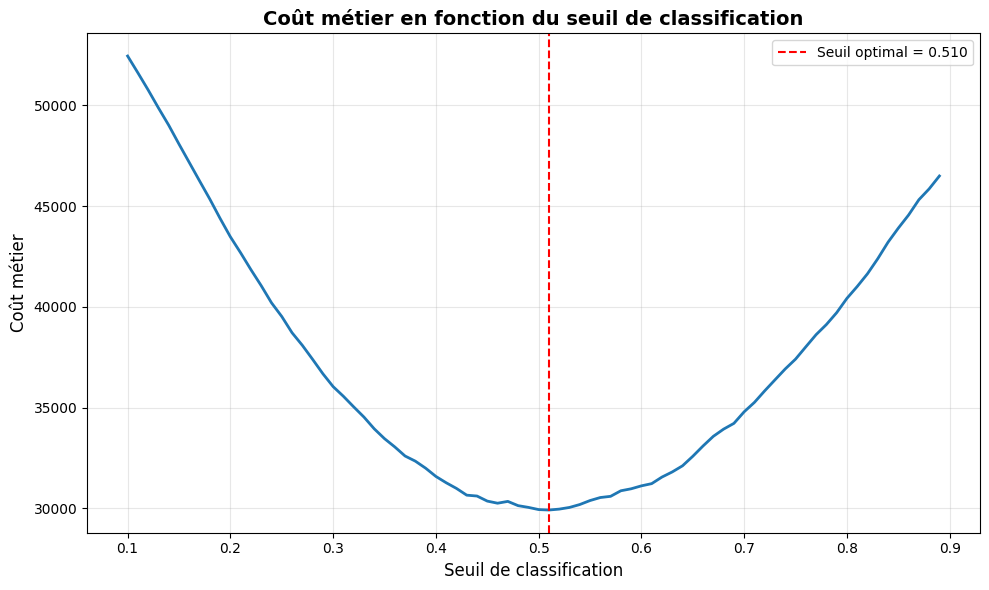

In [14]:
# Utiliser le meilleur modèle (XGBoost ou LightGBM ou MLP)
best_model = xgb_best # xgb_best  ou lgb_best ou mlp_best
y_proba_val = best_model.predict_proba(X_val)[:, 1]

# Trouver le seuil optimal
optimal_threshold, min_cost, costs = find_optimal_threshold(y_val, y_proba_val)

print(f"Seuil optimal: {optimal_threshold:.3f}")
print(f"Coût minimal: {min_cost:.2f}")

# Visualiser la courbe coût vs seuil
thresholds = list(costs.keys())
cost_values = list(costs.values())

plt.figure(figsize=(10, 6))
plt.plot(thresholds, cost_values, linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Seuil optimal = {optimal_threshold:.3f}')
plt.xlabel('Seuil de classification', fontsize=12)
plt.ylabel('Coût métier', fontsize=12)
plt.title('Coût métier en fonction du seuil de classification', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Comparer les performances avec différents seuils
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, optimal_threshold]

results_comparison = []
for threshold in thresholds_to_test:
    y_pred = (y_proba_val >= threshold).astype(int)
    cost = calculate_business_cost_from_proba(y_val, y_proba_val, threshold)
    
    from sklearn.metrics import accuracy_score, recall_score, precision_score
    
    results_comparison.append({
        'threshold': threshold,
        'cost': cost,
        'accuracy': accuracy_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred)
    })

df_comparison = pd.DataFrame(results_comparison)
print("Comparaison des seuils XGB:")
print(df_comparison.round(4))

Comparaison des seuils XGB:
   threshold   cost  accuracy  recall  precision
0       0.30  36045    0.4944  0.8892     0.1263
1       0.40  31590    0.6336  0.7974     0.1553
2       0.50  29946    0.7399  0.6878     0.1912
3       0.60  31123    0.8188  0.5529     0.2353
4       0.51  29924    0.7483  0.6767     0.1950


## 7. Entraînement final sur toutes les données XGB

In [16]:
# Entraîner le meilleur modèle sur toutes les données d'entraînement
final_model = xgb.XGBClassifier(**xgb_best.get_params())
final_model.fit(X_train, y_train)

# Sauvegarder le modèle
import joblib
joblib.dump(final_model, '../models/best_model_xgb.pkl')
print("[OK] Modele final sauvegarde")

# Sauvegarder le seuil optimal
import json
with open('../models/optimal_threshold_xgb.json', 'w') as f:
    json.dump({'optimal_threshold': float(optimal_threshold)}, f)
print(f"[OK] Seuil optimal sauvegarde: {optimal_threshold:.3f}")

[OK] Modele final sauvegarde
[OK] Seuil optimal sauvegarde: 0.510


## 8. Analyse du seuil optimal LightGBM

Seuil optimal: 0.530
Coût minimal: 29848.00


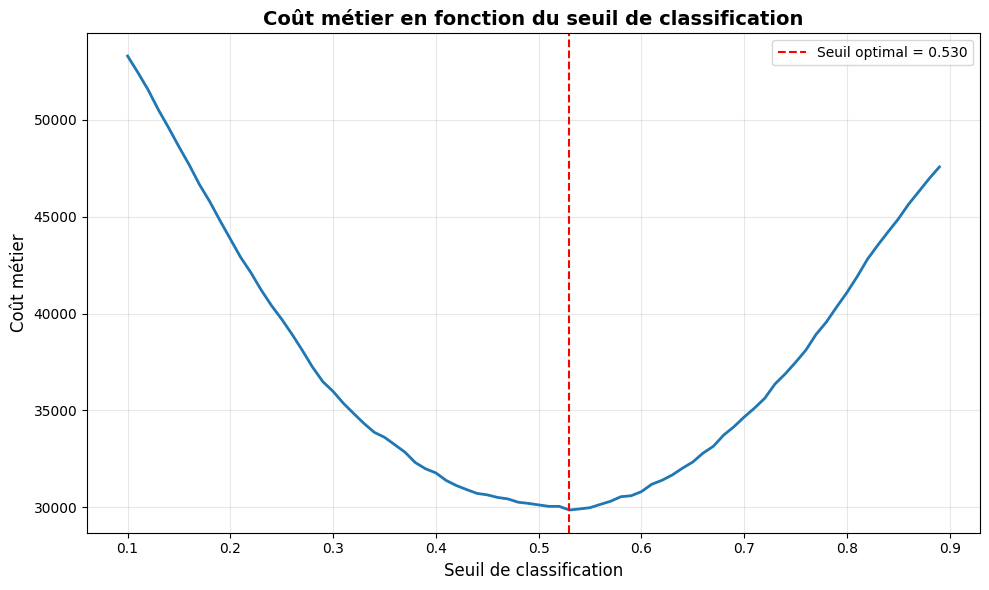

In [23]:
# Utiliser le meilleur modèle (XGBoost ou LightGBM ou MLP)
best_model3 = lgb_best # xgb_best  ou lgb_best ou mlp_best
y_proba_val = best_model3.predict_proba(X_val)[:, 1]

# Trouver le seuil optimal
optimal_threshold, min_cost, costs = find_optimal_threshold(y_val, y_proba_val)

print(f"Seuil optimal: {optimal_threshold:.3f}")
print(f"Coût minimal: {min_cost:.2f}")

# Visualiser la courbe coût vs seuil
thresholds = list(costs.keys())
cost_values = list(costs.values())

plt.figure(figsize=(10, 6))
plt.plot(thresholds, cost_values, linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Seuil optimal = {optimal_threshold:.3f}')
plt.xlabel('Seuil de classification', fontsize=12)
plt.ylabel('Coût métier', fontsize=12)
plt.title('Coût métier en fonction du seuil de classification', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Comparer les performances avec différents seuils
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, optimal_threshold]

results_comparison = []
for threshold in thresholds_to_test:
    y_pred = (y_proba_val >= threshold).astype(int)
    cost = calculate_business_cost_from_proba(y_val, y_proba_val, threshold)
    
    from sklearn.metrics import accuracy_score, recall_score, precision_score
    
    results_comparison.append({
        'threshold': threshold,
        'cost': cost,
        'accuracy': accuracy_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred)
    })

df_comparison = pd.DataFrame(results_comparison)
print("Comparaison des seuils LightGBM:")
print(df_comparison.round(4))

Comparaison des seuils LightGBM:
   threshold   cost  accuracy  recall  precision
0       0.30  35974    0.4928  0.8931     0.1263
1       0.40  31765    0.6301  0.7982     0.1542
2       0.50  30113    0.7341  0.6920     0.1882
3       0.60  30798    0.8158  0.5644     0.2341
4       0.53  29848    0.7614  0.6604     0.2016


## 9. Entraînement final sur toutes les données LightGBM

In [28]:
# Entraîner le meilleur modèle sur toutes les données d'entraînement
final_model = lgb.LGBMClassifier(**lgb_best.get_params())
final_model.fit(X_train, y_train)

# Sauvegarder le modèle
import joblib
joblib.dump(final_model, '../models/best_model_lgb.pkl')
print("[OK] Modele final sauvegarde")

# Sauvegarder le seuil optimal
import json
with open('../models/optimal_threshold_lgb.json', 'w') as f:
    json.dump({'optimal_threshold': float(optimal_threshold)}, f)
print(f"[OK] Seuil optimal sauvegarde: {optimal_threshold:.3f}")

[OK] Modele final sauvegarde
[OK] Seuil optimal sauvegarde: 0.530


## 10. Analyse du seuil optimal MLP

Seuil optimal: 0.100
Coût minimal: 30961.00


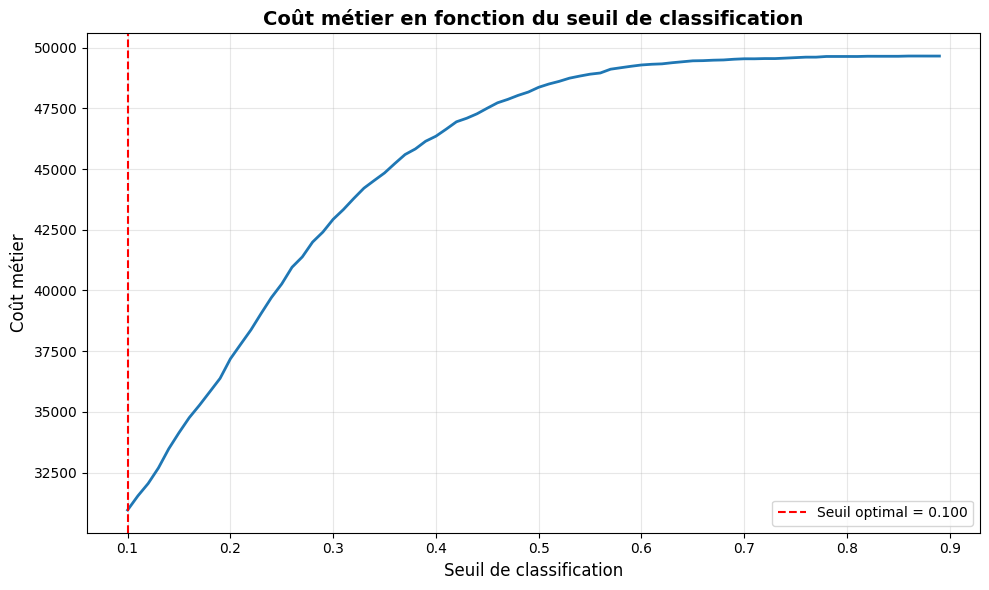

In [18]:
# Utiliser le meilleur modèle (XGBoost ou LightGBM ou MLP)
best_model2 = mlp_best # xgb_best  ou lgb_best ou mlp_best

# Pour MLP : le modele n'a que les hyperparametres Optuna, il n'a jamais ete fit.
# On l'entraine sur les donnees normalisees puis on utilise X_val_scaled pour predict_proba.
if isinstance(best_model2, MLPClassifier):
    best_model2.fit(X_train_scaled_df, y_train_split)
    y_proba_val = best_model2.predict_proba(X_val_scaled)[:, 1]
else:
    y_proba_val = best_model2.predict_proba(X_val)[:, 1]
# Trouver le seuil optimal
optimal_threshold, min_cost, costs = find_optimal_threshold(y_val, y_proba_val)

print(f"Seuil optimal: {optimal_threshold:.3f}")
print(f"Coût minimal: {min_cost:.2f}")

# Visualiser la courbe coût vs seuil
thresholds = list(costs.keys())
cost_values = list(costs.values())

plt.figure(figsize=(10, 6))
plt.plot(thresholds, cost_values, linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Seuil optimal = {optimal_threshold:.3f}')
plt.xlabel('Seuil de classification', fontsize=12)
plt.ylabel('Coût métier', fontsize=12)
plt.title('Coût métier en fonction du seuil de classification', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Enregistrer le MLP optimise dans MLflow (comme XGBoost et LightGBM)
metrics_mlp = evaluate_model(y_val, (y_proba_val >= optimal_threshold).astype(int), y_proba_val)
metrics_to_log = {k: float(v) if isinstance(v, (np.floating, np.integer)) else v for k, v in metrics_mlp.items() if isinstance(v, (int, float, np.number))}
with mlflow.start_run(run_name="MLP_optimized"):
    mlflow.log_params(mlp_best.get_params())
    mlflow.log_metrics(metrics_to_log)
    mlflow.sklearn.log_model(mlp_best, "model")
print("[OK] MLP optimise enregistre dans MLflow")

[OK] MLP optimise enregistre dans MLflow


In [19]:
# Comparer les performances avec différents seuils
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, optimal_threshold]

results_comparison = []
for threshold in thresholds_to_test:
    y_pred = (y_proba_val >= threshold).astype(int)
    cost = calculate_business_cost_from_proba(y_val, y_proba_val, threshold)
    
    from sklearn.metrics import accuracy_score, recall_score, precision_score
    
    results_comparison.append({
        'threshold': threshold,
        'cost': cost,
        'accuracy': accuracy_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred)
    })

df_comparison = pd.DataFrame(results_comparison)
print("Comparaison des seuils MLP:")
print(df_comparison.round(4))

Comparaison des seuils MLP:
   threshold   cost  accuracy  recall  precision
0        0.3  42930    0.9122  0.1601     0.3926
1        0.4  46351    0.9183  0.0751     0.4639
2        0.5  48365    0.9194  0.0286     0.5126
3        0.6  49284    0.9194  0.0081     0.5405
4        0.1  30961    0.7713  0.6220     0.2021


## 11. Entraînement final sur toutes les données MLP

In [21]:
# Entraîner le meilleur modèle sur toutes les données d'entraînement
final_model = MLPClassifier(**mlp_best.get_params())
final_model.fit(X_train, y_train)

# Sauvegarder le modèle
import joblib
joblib.dump(final_model, '../models/best_model_mlp.pkl')
print("[OK] Modele final MLP sauvegarde")

# Sauvegarder le seuil optimal
import json
with open('../models/optimal_threshold_mlp.json', 'w') as f:
    json.dump({'optimal_threshold': float(optimal_threshold)}, f)
print(f"[OK] Seuil optimal sauvegarde: {optimal_threshold:.3f}")

[OK] Modele final MLP sauvegarde
[OK] Seuil optimal sauvegarde: 0.100
